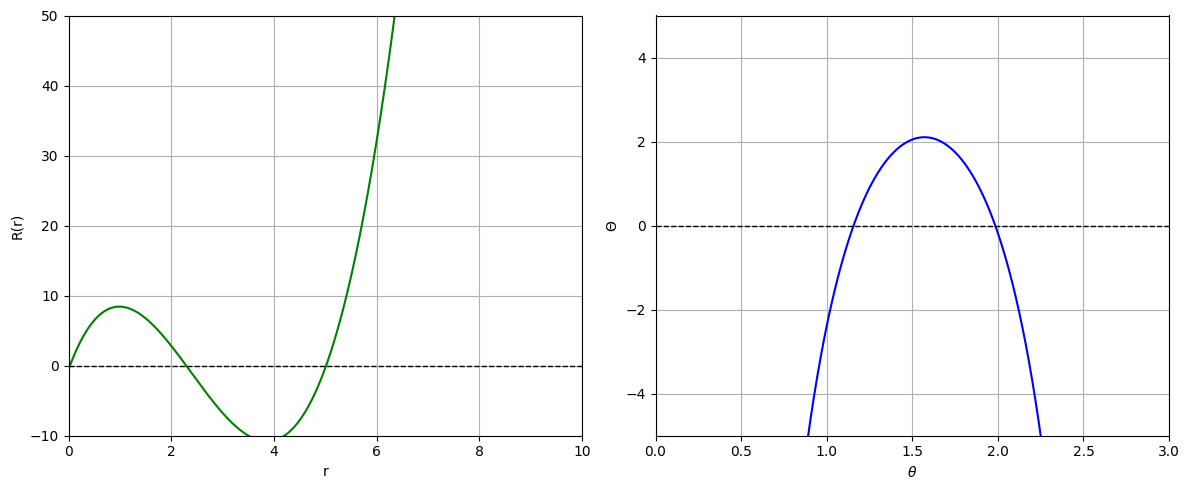

In [13]:
#Config and plotting effective potentials
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from scipy.integrate import solve_ivp
from scipy.integrate import quad
from scipy.interpolate import CubicSpline
from scipy.optimize import brentq
# Constants
E = 0.98
Lz = 3.3
a = 0.5
k = 10.0
M = 1.0
epsilon = -0.001
H1 = epsilon*(Lz - 2*a*E)

#Functions
def delta(r):
    return r**2 - 2 * M * r + a**2


def R_pot(r):
    R1 = (E * (r**2 + a**2) - a * Lz) ** 2
    R2 = (delta(r)) * (k + r**2)
    return R1 - R2 - (r**2)*H1


def Theta_pot(theta):
    Theta1 = k + 2 * a * E * Lz
    Theta2 = (
        (a * np.cos(theta)) ** 2
        + (Lz / np.sin(theta)) ** 2
        + (a * E * np.sin(theta)) ** 2
    )
    return Theta1 - Theta2 - (a*np.cos(theta))**2*H1


r_vals = np.linspace(0, 50, 10000)
theta_vals = np.linspace(1e-4, np.pi - 1e-4, 10000)

R_vals = R_pot(r_vals)
Theta_vals = Theta_pot(theta_vals)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.plot(r_vals, R_vals, color="green", label="R(r)")
ax1.axhline(0, color="black", linestyle="--", linewidth=1)
ax1.set_xlabel("r")
ax1.set_ylabel("R(r)")
ax1.grid(True)
ax1.set_xlim(0, 10)
ax1.set_ylim(-10, 50)

ax2.plot(theta_vals, Theta_vals, color="blue", label=r"$\Theta(\theta)$")
ax2.axhline(0, color="black", linestyle="--", linewidth=1)
ax2.set_xlabel(r"$\theta$")
ax2.set_ylabel(r"$\Theta$")
ax2.set_ylim(-5, 5)
ax2.set_xlim(0, 3)
ax2.grid(True)

plt.tight_layout()
plt.show()

In [14]:
#getting roots
#It's faster for brentq if you provide approximate location of roots
periap_min = 4
periap_max = 6
ap_min = 40
ap_max = 44

r_periapsis = brentq(R_pot, periap_min, periap_max, xtol = 2e-15)
r_apoapsis = brentq(R_pot, ap_min, ap_max, xtol = 2e-15)

theta1_min = 1.1
theta1_max = 1.2
theta2_min = 1.98
theta2_max = 2

theta_min = brentq(Theta_pot, theta1_min, theta1_max)
theta_max = brentq(Theta_pot, theta2_min, theta2_max)

print(r_periapsis, r_apoapsis, theta_min, theta_max)

5.015375439989611 43.17071759134334 1.1568067952816985 1.9847858583080946


/tmp/ipykernel_7488/2446904823.py:15: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  quad(radial_integrand, r_periapsis, r,
/tmp/ipykernel_7488/2446904823.py:15: IntegrationWarning: The maximum number of subdivisions (50) has been achieved.
  If increasing the limit yields no improvement it is advised to analyze 
  the integrand in order to determine the difficulties.  If the position of a 
  local difficulty can be determined (singularity, discontinuity) one will 
  probably gain from splitting up the interval and calling the integrator 
  on the subranges.  Perhaps a special-purpose integrator should be used.
  quad(radial_integrand, r_periapsis, r,


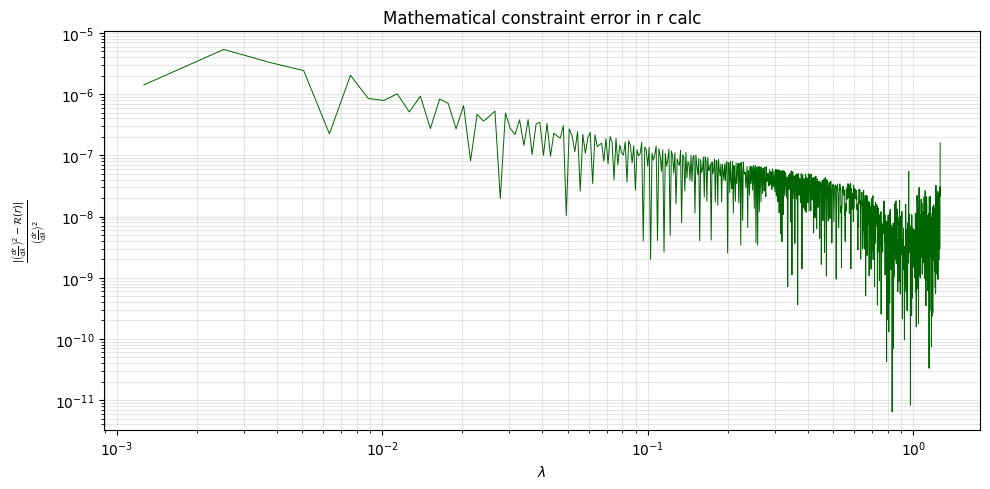

In [15]:

def radial_integrand(r):
    val = R_pot(r)
    return 1.0 / np.sqrt(max(1e-14, val)) 
#Setting up chebyshev grid. Its denser near interval endpoints, where this integral is most difficult to evaluate.
N_points = 1000
x_cheb = np.linspace(0, np.pi, N_points)
r_grid = r_periapsis + (r_apoapsis - r_periapsis) * (1 - np.cos(x_cheb)) / 2
'''Quad, or adaptive quadrature is an integrator. Here its just calculating lambda(r) for each point in the r_grid.
It first computes two integrals using a numerical integration method, one with 4th order and one with 5th order of accuracy. It compares the results to get an estimate of the truncation error.
If the error is larger then the tolerances, it further subdivides the interval and integrates recursively until error is within the limits. Max subdivisions by default is 50.
The integrator is run for all intervals [r_periapsis, r], giving the lambda needed to reach each r in the grid.
The points argument ensures the integrator samples the endpoints also.
The epsabs and epsrel arguments set the absolute and relative error tolerances. '''
lambda_r_values = [
    quad(radial_integrand, r_periapsis, r, 
         points=[r_periapsis, r_apoapsis], 
         epsabs=1e-12, epsrel=1e-12)[0] 
    for r in r_grid
]
#Interpolating to get r(lambda) using a cubic spline. bc-type is boundary condition, here set to clamped, so first derivative(would be dr/dlambda here) at endpoints is zero(apoapsis and periapsis for r)
r_of_lam = CubicSpline(lambda_r_values, r_grid, bc_type=((1, 0.0), (1, 0.0)))

lam_plot = np.linspace(0, lambda_r_values[-1], 1000)
r_traj = r_of_lam(lam_plot)
dr_dlam_spline = r_of_lam(lam_plot, 1)

R_vals_traj = np.array([R_pot(r) for r in r_traj])
#Mask avoids absurdly large errors from floating point noise
mask = np.abs(dr_dlam_spline**2) > 1e-10
abs_error_cheb = np.full_like(dr_dlam_spline, np.nan)
abs_error_cheb[mask] = np.abs(dr_dlam_spline[mask]**2 - R_vals_traj[mask]) / dr_dlam_spline[mask]**2

plt.figure(figsize=(10, 5))
plt.plot(lam_plot, abs_error_cheb, color='darkgreen', lw=0.7)
plt.yscale('log')
plt.xscale('log')
plt.title('Mathematical constraint error in r calc')
plt.ylabel(r'$\frac{|\left(\frac{dr}{d\lambda}\right)^2 - \mathcal{R}(r)|}{\left(\frac{dr}{d\lambda}\right)^2}$')
plt.xlabel(r'$\lambda$')
plt.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

/tmp/ipykernel_7488/1394678926.py:12: IntegrationWarning: The algorithm does not converge.  Roundoff error is detected
  in the extrapolation table.  It is assumed that the requested tolerance
  cannot be achieved, and that the returned result (if full_output = 1) is 
  the best which can be obtained.
  quad(theta_integrand, theta_min, th,


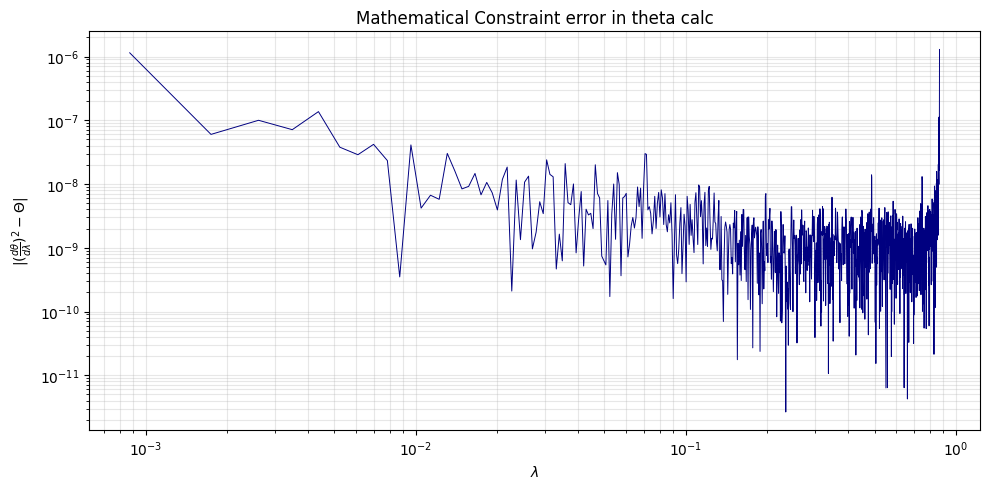

In [16]:
#Same process as above for theta
def theta_integrand(th):
    val = Theta_pot(th)
    return 1.0 / np.sqrt(max(1e-16, val))

N_points_th = 1000
x_cheb_th = np.linspace(0, np.pi, N_points_th)

th_grid = theta_min + (theta_max - theta_min) * (1 - np.cos(x_cheb_th)) / 2

lambda_th_values = [
    quad(theta_integrand, theta_min, th, 
         points=[theta_min, theta_max], 
         epsabs=1e-12, epsrel=1e-12)[0] 
    for th in th_grid
]

th_of_lam = CubicSpline(lambda_th_values, th_grid)

lam_plot_th = np.linspace(0, lambda_th_values[-1], 1000)
th_traj = th_of_lam(lam_plot_th)
dth_dlam_spline = th_of_lam(lam_plot_th, 1)

Theta_vals_traj = np.array([Theta_pot(th) for th in th_traj])
mask_th = np.abs(dth_dlam_spline**2) > 1e-10
abs_error_th = np.full_like(dth_dlam_spline, np.nan)
abs_error_th[mask_th] = np.abs(dth_dlam_spline[mask_th]**2 - Theta_vals_traj[mask_th]) / dth_dlam_spline[mask_th]**2

plt.figure(figsize=(10, 5))
plt.plot(lam_plot_th, abs_error_th, color='navy', lw=0.7)
plt.xscale('log')
plt.yscale('log')
plt.title('Mathematical Constraint error in theta calc')
plt.ylabel(r'$|(\frac{d\theta}{d\lambda})^2 - \Theta|$')
plt.xlabel(r'$\lambda$')
plt.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.show()

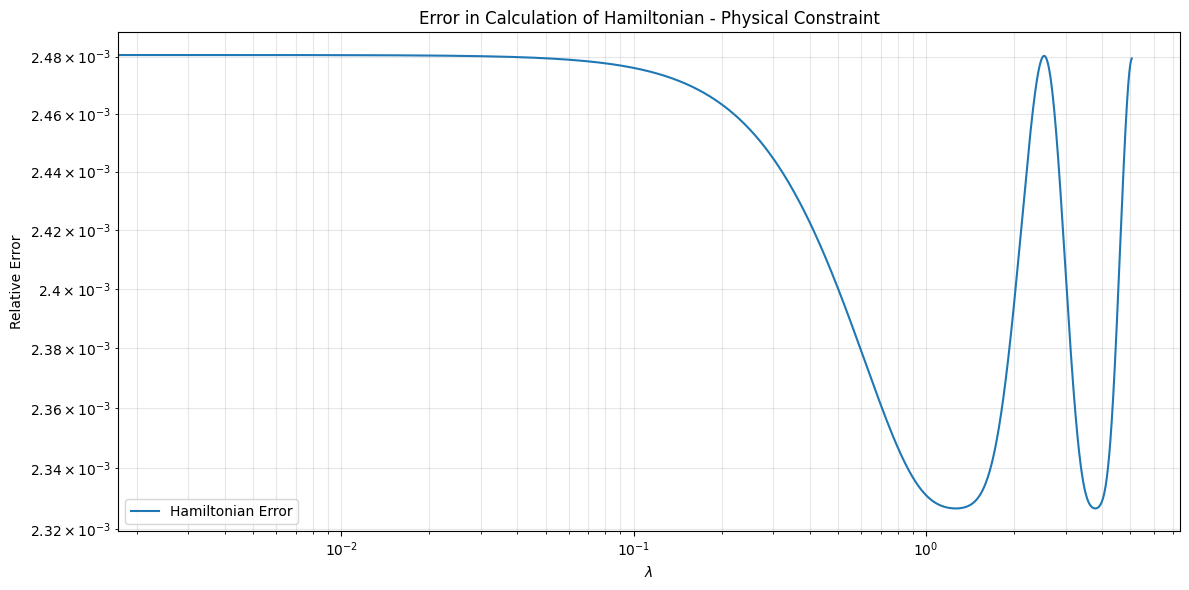

Mean error: 0.0023879150554966615
RMS error: 0.002388549012495566
Max error: 0.00248053226812069


In [17]:
def get_hamiltonian_error(r_vals, th_vals, dr_vals, dth_vals, E, Lz, a, M=1.0):

    Sigma = r_vals**2 + (a * np.cos(th_vals))**2
    Delta = r_vals**2 - 2*M*r_vals + a**2
    sin2 = np.sin(th_vals)**2
    
    Pr = dr_vals / Delta
 
    Pth = dth_vals
    
    term_radial_E_L = -1.0/Delta * ((r_vals**2 + a**2)*E - a*Lz)**2
    term_radial_kinetic = Delta * Pr**2
    pert_radial = (r_vals**2)*H1
    H_radial_part = term_radial_E_L + term_radial_kinetic - pert_radial
    
    term_angular_E_L = (a*E*np.sqrt(sin2) - Lz/np.sqrt(sin2))**2
    term_angular_kinetic = Pth**2
    pert_angular = (a*np.cos(th_vals))**2*H1
    H_angular_part = term_angular_E_L + term_angular_kinetic - pert_angular

    H_calc = (H_radial_part + H_angular_part) / (2 * Sigma) 
    
    return np.abs((-0.5 - H_calc) / H_calc)

#Because theta and r have different periods, the results need to be extended and joined.
def extend_trajectory(lam_half, val_half, target_lambda):
    
    period_half = lam_half[-1]
    
    lam_full = [lam_half]
    val_full = [val_half]
    
    current_lambda = period_half
    direction = -1 
    
    while current_lambda < target_lambda:
      
        next_vals = val_half[::-1][1:] if direction == -1 else val_half[1:]
      
        next_lams = current_lambda + (period_half - lam_half[::-1] if direction == -1 else lam_half)[1:]
        
        lam_full.append(next_lams)
        val_full.append(next_vals)
      
        current_lambda = next_lams[-1]
        direction *= -1
        
    return np.concatenate(lam_full), np.concatenate(val_full)
#Joining data to span multiple orbits
L_r_half = lambda_r_values[-1]
target_lambda = 4 * L_r_half * 1.1  #1.1 is just what I thought half period of r looked like. Doesn't matter much


lam_r_ext, r_ext = extend_trajectory(np.array(lambda_r_values), r_grid, target_lambda)
lam_th_ext, th_ext = extend_trajectory(np.array(lambda_th_values), th_grid, target_lambda)

r_spline_ext = CubicSpline(lam_r_ext, r_ext)
th_spline_ext = CubicSpline(lam_th_ext, th_ext)

lam_plot = np.linspace(0, 4 * L_r_half, 2000) 

r_vals = r_spline_ext(lam_plot)
th_vals = th_spline_ext(lam_plot)
dr_vals = r_spline_ext(lam_plot, 1)
dth_vals = th_spline_ext(lam_plot, 1)

error = get_hamiltonian_error(r_vals, th_vals, dr_vals, dth_vals, E, Lz, a)

error_clean = error.copy()
#error_clean[error > 0.01] = np.nan
plt.figure(figsize=(12, 6))
plt.plot(lam_plot, error_clean, label='Hamiltonian Error')
plt.yscale('log')
plt.xscale('log')
plt.title(r'Error in Calculation of Hamiltonian - Physical Constraint')
plt.ylabel('Relative Error')
plt.xlabel(r'$\lambda$')
plt.legend()
plt.grid(True, which='both', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Mean error: {np.mean(error_clean)}\nRMS error: {np.sqrt(np.mean(error_clean**2))}\nMax error: {np.max(error_clean)}')

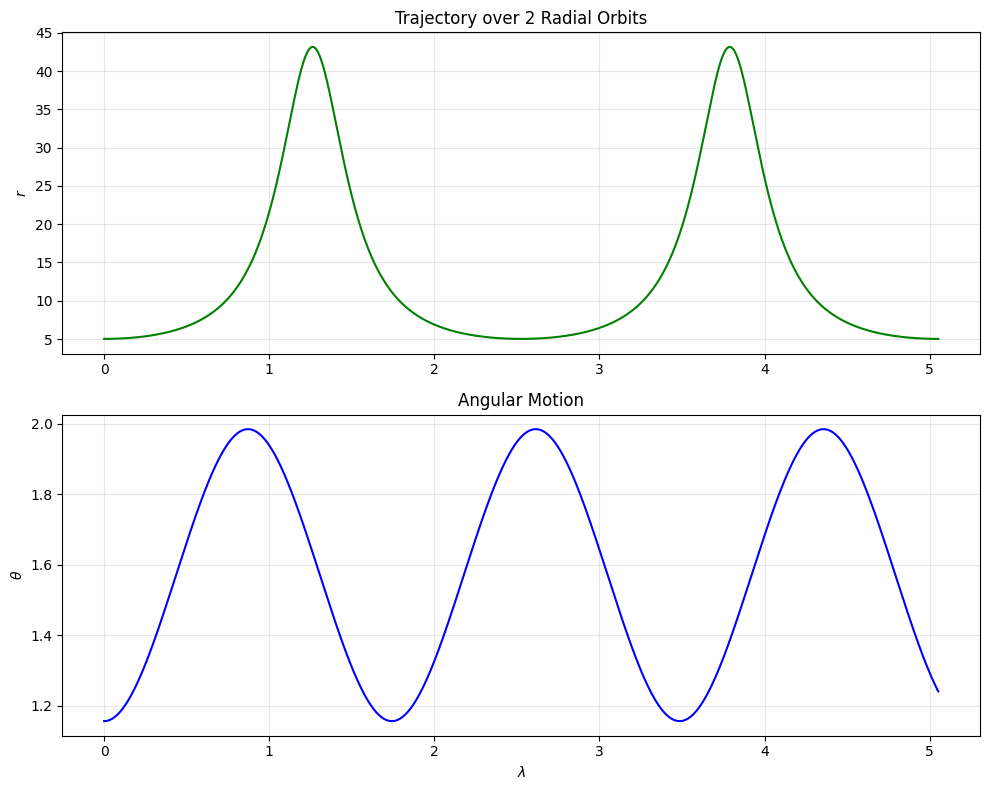

In [18]:
# To stitch solution and plot over multiple orbits \
#Doesn't do any new solving. Because solution is symmetric, I can just extend it. This is only to show the trajectory in a beautiful way. The solver can be ran in a loop over a range of lambda and then stiched with spline.
def extend_oscillation(lam_half, val_half, target_max_lambda):
    lam_full = list(lam_half)
    val_full = list(val_half)
    
    current_lam = lam_half[-1]
    direction = -1 
    
    while current_lam < target_max_lambda:
        dt = np.diff(lam_half)
        if direction == -1:
            dt = dt[::-1]
            next_vals = val_half[::-1]
        else:
            next_vals = val_half
            
        new_times = current_lam + np.cumsum(dt)
        lam_full.extend(new_times)
        val_full.extend(next_vals[1:])
        
        current_lam = new_times[-1]
        direction *= -1
        
    return np.array(lam_full), np.array(val_full)

radial_half_period = lambda_r_values[-1]
target_time = 4 * radial_half_period


lam_r_ext, r_ext = extend_oscillation(lambda_r_values, r_grid, target_time)
lam_th_ext, th_ext = extend_oscillation(lambda_th_values, th_grid, target_time)

#Simple linear interpolation
r_of_lam_long = interp1d(lam_r_ext, r_ext, kind='linear') 
th_of_lam_long = interp1d(lam_th_ext, th_ext, kind='linear')

lam_plot_long = np.linspace(0, target_time, 1000)
r_traj_long = r_of_lam_long(lam_plot_long)
th_traj_long = th_of_lam_long(lam_plot_long)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8))

ax1.plot(lam_plot_long, r_traj_long, color='green', lw=1.5)
ax1.set_ylabel(r'$r$')
ax1.set_title(r'Trajectory over 2 Radial Orbits')
ax1.grid(True, alpha=0.3)

ax2.plot(lam_plot_long, th_traj_long, color='blue', lw=1.5)
ax2.set_ylabel(r'$\theta$')
ax2.set_xlabel(r'$\lambda$')
ax2.set_title(r'Angular Motion')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()